<a href="https://colab.research.google.com/github/Julianpucheta/OptimalControl/blob/main/Identificacion_Exacta/Motor_2025_CODINOA_Estimacion_Identificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistemas de primer orden
Observando la respuesta al escalón en el tiempo de un sistema, si la derivada inicial es muy grande, entonces puede emplearse el método de primer orden con retardo puro. Se puede realizar la identificación de los parámetros a partir de la respuesta al escalón, función Heaviside.
Sea la función prototipo

$G=\frac{Y(s)}{U(s)}=g_1\frac{1}{T_1s+1}  $

cuando se aplica un escalón de amplitud $A$, sería $U(s)=\frac{A}{s}$, por lo que la excursión final del sistema será $g=g_1\cdot A$. En la figura siguiente se detalla el resultado en el dominio temporal, que es donde se tomarán las mediciones de $y(t)$.



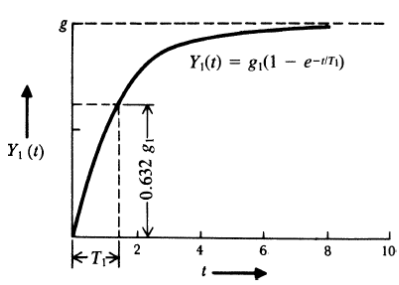

### Instala librerías y estilos para imprimir en Matplotlib

In [ ]:
!pip install -U control qtpy;

In [2]:
import matplotlib.pyplot as plt

In [ ]:
# # sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super
# !apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super

In [ ]:
!pip install SciencePlots # !pip install git+https://github.com/garrettj403/SciencePlots

In [4]:
import scienceplots

In [ ]:
# plt.style.available #tienen que aparecer science y ieee

In [5]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
# import math
import control as ctrl
from control.matlab import * #permite escribir igual que en Matlab
import cmath as cm

# Recomendaciones finales y conclusiones de sistemas de ejemplo y RLC
Se ha logrado identificar con un error aceptable las funciones de transferencia de primer y segundo orden.


In [ ]:
!apt install megatools

In [74]:
!megadl 'https://mega.nz/file/bgpXEBZI#cuYbd_6JKybi3-jN62BfpLY970EzRxkhaFOBuFuwrT0'

Downloaded Curvas_Medidas_Motor_2025_v.xls


# Cálculo de parámetros del Motor CC 2025

In [75]:
df_Motor = pd.read_excel('Curvas_Medidas_Motor_2025_v.xls', header=(0)) # carga desde Colab

In [76]:
df_Motor.head(3)

,0.001,0,0.1,0.2,0.3
0,0.002,0.0,0.0,0,0.0
1,0.003,0.0,0.0,0,0.0
2,0.004,0.0,0.0,0,0.0


In [79]:
df_Motor.head(3)

,t,wr,i_t,Vin,TL
0,0.002,0.0,0.0,0,0.0
1,0.003,0.0,0.0,0,0.0
2,0.004,0.0,0.0,0,0.0


In [78]:
df_Motor.columns = ['t', 'wr', 'i_t', 'Vin', 'TL'] #Renombro las columnas
df_Motor.tail(3)

,t,wr,i_t,Vin,TL
1496,1.498,7.618140,0.042110,2,0.0
1497,1.499,7.618339,0.042088,2,0.0
1498,1.500,7.618536,0.042065,2,0.0


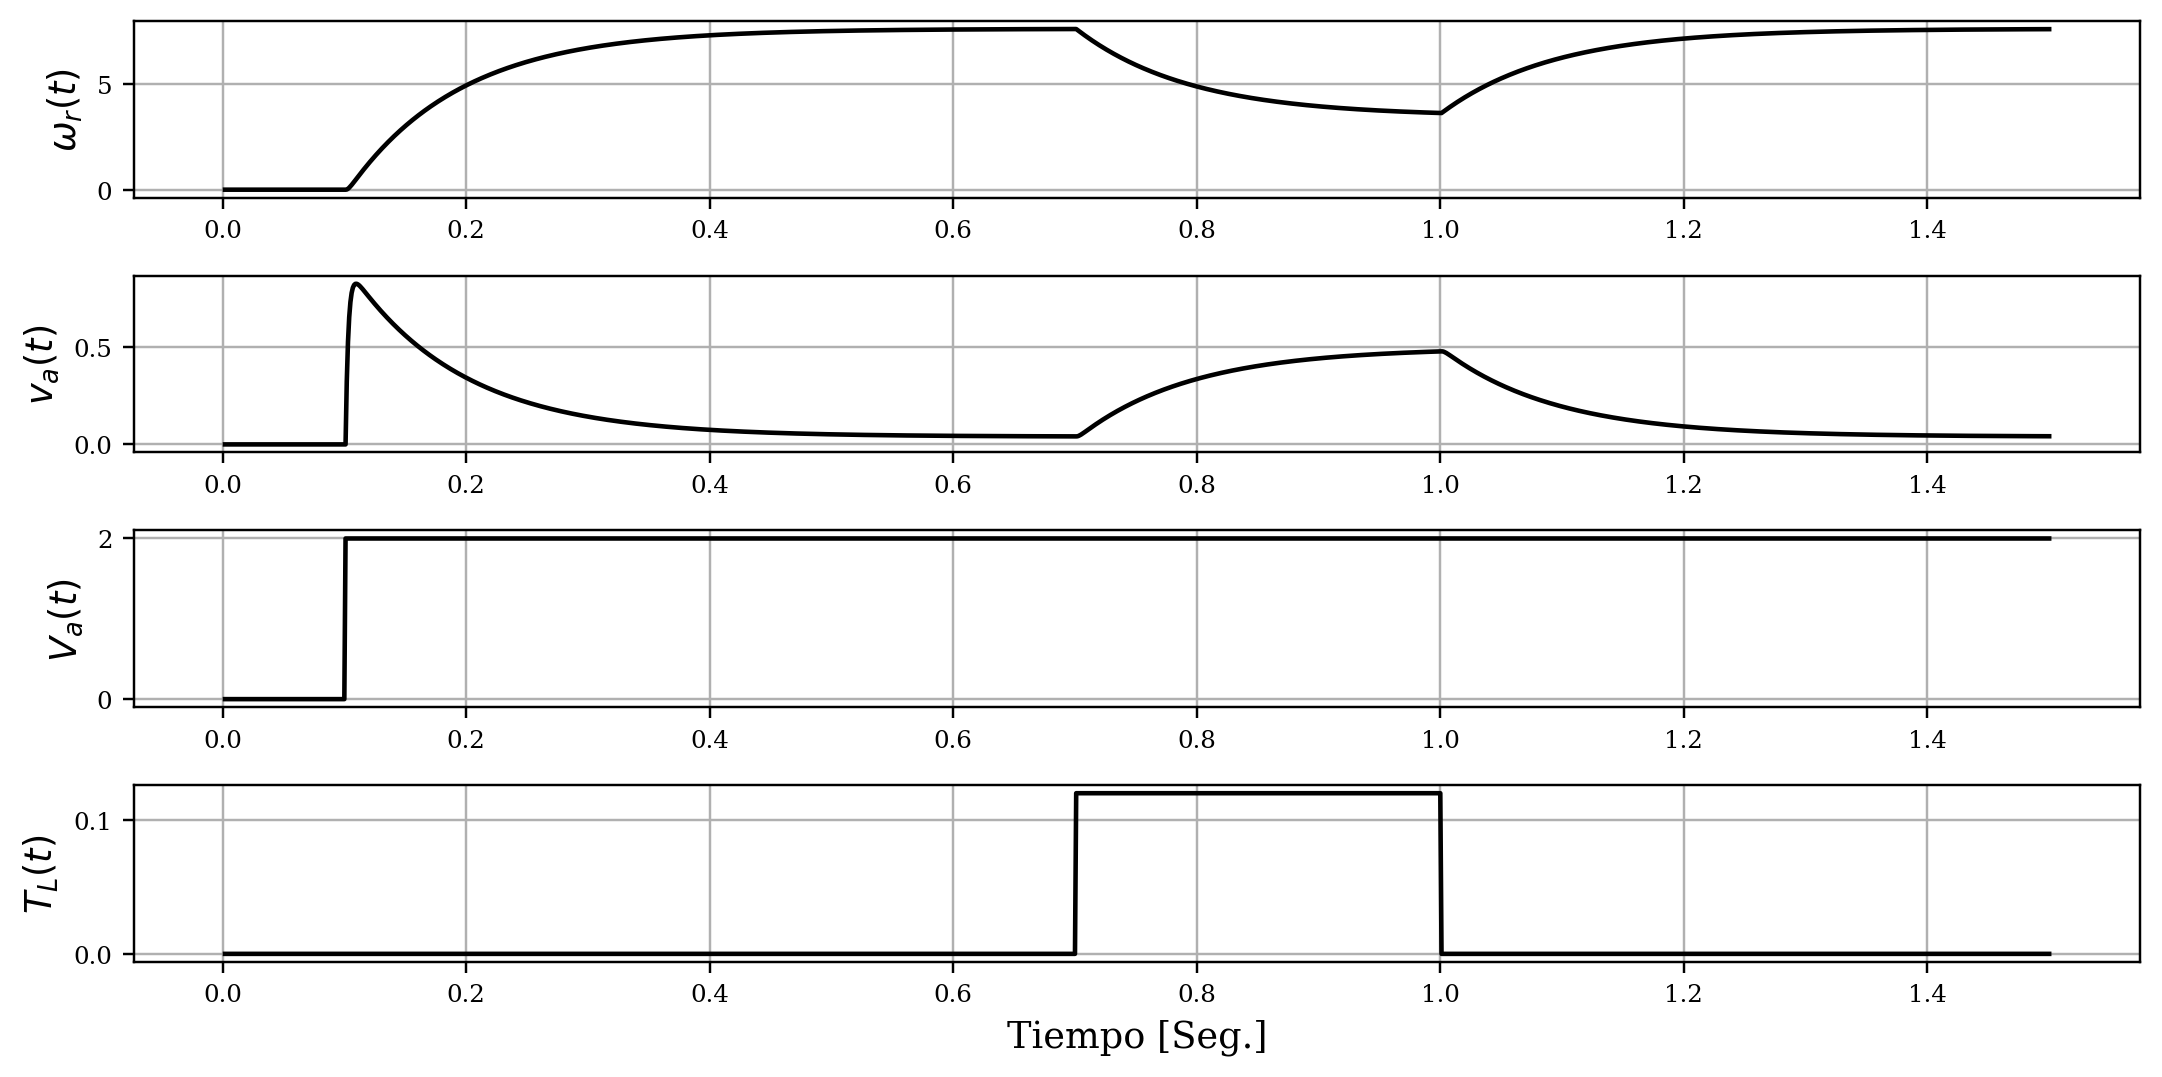

In [80]:
df=df_Motor
with plt.style.context('ieee'): #
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig10, ax13 = plt.subplots(4,1,figsize=(10,5), dpi= 220)
ax13[0].plot(df['t'],df['wr'])
ax13[0].set_ylabel(r'$\omega_r{(t)}$',rotation=90, fontsize=12)
ax13[0].grid( True )
ax13[1].plot(df['t'],df['i_t'])
ax13[1].set_ylabel(r'$v_a{(t)}$',rotation=90, fontsize=12)
ax13[1].grid( True )
ax13[2].plot(df['t'],df['Vin'])
ax13[2].set_ylabel(r'$V_a{(t)}$',rotation=90, fontsize=12)
ax13[2].grid( True )
ax13[3].plot(df['t'],df['TL'])
ax13[3].set_ylabel(r'$T_L{(t)}$',rotation=90, fontsize=12)
ax13[3].grid( True )
ax13[3].set_xlabel(r'Tiempo [Seg.]',rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [81]:
df_Motor.tail(3)

,t,wr,i_t,Vin,TL
1496,1.498,7.618140,0.042110,2,0.0
1497,1.499,7.618339,0.042088,2,0.0
1498,1.500,7.618536,0.042065,2,0.0


## Motor CC 2025

### Código de referencia extraído de [acá](https://github.com/Julianpucheta/OptimalControl/blob/main/Ide_Chen_Interactivo.ipynb)

In [82]:
t_D = np.array(df_Motor['t'], dtype=np.float64)
y_D=np.array(df_Motor['wr'], dtype=np.float64)
u=np.array(df_Motor['Vin'], dtype=np.float64)
TL=np.array(df_Motor['TL'], dtype=np.float64)

# Parámetros iniciales
StepAmplitude = 2  # 2 V de entrada en Va
ret = .103
t = .05

# Buscar puntos para t1, t2, t3
def find_closest(t_target, t_D, y_D):
    idx = np.argmin(np.abs(t_target - t_D))
    return y_D[idx], t_D[idx], idx

y_t, t_val, lugar = find_closest(t + ret, t_D, y_D)
t = t_val - ret  # t1

y_t2, t_val2, lugar = find_closest(2 * t + ret, t_D, y_D)
t2 = t_val2 - ret

y_t3, t_val3, lugar = find_closest(3 * t + ret, t_D, y_D)
t3 = t_val3 - ret

# Ganancia k
k =7.625 / 2.

# Método de Chen
k1 = (1 / StepAmplitude) * y_t / k - 1
k2 = (1 / StepAmplitude) * y_t2 / k - 1
k3 = (1 / StepAmplitude) * y_t3 / k - 1
b = 4 * (k1**3) * k3 - 3 * (k1**2) * (k2**2) - 4 * (k2**3) + (k3**2) + 6 * k1 * k2 * k3
alfa1 = (k1 * k2 + k3 - np.sqrt(b)) / (2 * (k1**2 + k2))
alfa2 = (k1 * k2 + k3 + np.sqrt(b)) / (2 * (k1**2 + k2))
beta = (2 * k1**3 + 3 * k1 * k2 + k3 - np.sqrt(b)) / np.sqrt(b)

T1 = -t / np.log(alfa1)
T2 = -t / np.log(alfa2)
T1 = np.real(T1)
T2 = np.real(T2)
T3 = np.real(beta * (T1 - T2) + T1)

# Sistema de transferencia Va
sys_va=k*tf([1],np.convolve([T1, 1],[T2, 1]))
# Simulación para Va
[y1, t1_, x1] = lsim(sys_va, U=u, T=t_D, X0=[0, 0])

/usr/local/lib/python3.11/dist-packages/control/timeresp.py:1082: UserWarning:

return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.

/usr/local/lib/python3.11/dist-packages/control/timeresp.py:1088: UserWarning:

Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.



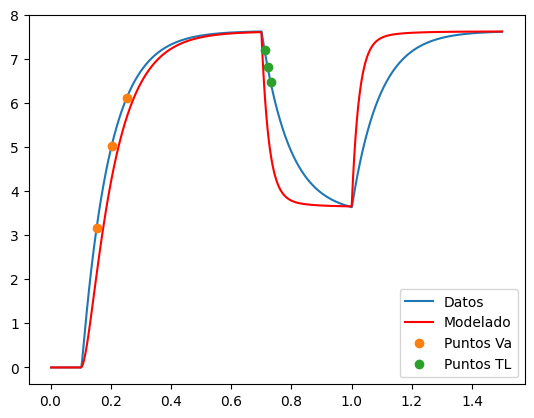

In [83]:
# Parte para TL
ret_tl = .701
t_tl = .01
y_t_tl, t_val_tl, lugar = find_closest(t_tl + ret_tl, t_D, y_D)
# t_tl = t_val_tl - ret_tl

y_t2_tl, t_val2_tl, lugar = find_closest(2 * t_tl + ret_tl, t_D, y_D)
t2_tl = t_val2_tl - ret_tl

y_t3_tl, t_val3_tl, lugar = find_closest(3 * t_tl + ret_tl, t_D, y_D)
t3_tl = t_val3_tl - ret_tl
# % K=y(00)/U
# w_001=7.635; %Omega en estado estacionario SIN TL
# w_002=3.656; %Omega en estado estacionario CON TL
# k_tl       =       -(w_002-w_001)/TL;
w_001=7.635
w_002=3.6561
TL_ = .12  # Amplitud del escalón de torque
k_tl = -(w_002 - w_001) / TL_

# Corrección de y para TL
yid_1 = -(y_t_tl - w_001)
yid_2 = -(y_t2_tl - w_001)
yid_3 = -(y_t3_tl - w_001)

k1_tl = (1 / TL_) * yid_1 / k_tl - 1
k2_tl = (1 / TL_) * yid_2 / k_tl - 1
k3_tl = (1 / TL_) * yid_3 / k_tl - 1
# b_tl= 4*k1_tl^3*k3_tl-3*k1_tl^2*k2_tl^2-4*k2_tl^3+k3_tl^2+6*k1_tl*k2_tl*k3_tl;
b_tl = 4*(k1_tl**3) * k3_tl - 3 * (k1_tl**2) * (k2_tl**2) - 4 * (k2_tl**3) + k3_tl**2 + 6 * k1_tl * k2_tl * k3_tl

if b_tl > 0: #Cambiar el cálculo para usar números complejos
  # alfa1=(k1*k2+k3-np.sqrt(be))/(2*(k1**2+k2))
  # alfa2=(k1*k2+k3+np.sqrt(be))/(2*(k1**2+k2))
  alfa1_tl = (k1_tl * k2_tl + k3_tl - np.sqrt(b_tl)) / (2 * (k1_tl**2 + k2_tl))
  alfa2_tl = (k1_tl * k2_tl + k3_tl + np.sqrt(b_tl)) / (2 * (k1_tl**2 + k2_tl))
else :
  # alfa1=(k1*k2+k3-cm.sqrt(be))/(2*(k1**2+k2))
  # alfa2=(k1*k2+k3+cm.sqrt(be))/(2*(k1**2+k2))
  alfa1_tl = (k1_tl * k2_tl + k3_tl - cm.sqrt(b_tl)) / (2 * (k1_tl**2 + k2_tl))
  alfa2_tl = (k1_tl * k2_tl + k3_tl + cm.sqrt(b_tl)) / (2 * (k1_tl**2 + k2_tl))
beta_tl = (2 * (k1_tl**3) + 3 * k1_tl * k2_tl + k3_tl - np.sqrt(b_tl)) / np.sqrt(b_tl)
T1_tl = -t_tl / cm.log(alfa1_tl)
T2_tl = -t_tl / cm.log(alfa2_tl)
T1_tl = np.real(T1_tl)
T2_tl = np.real(T2_tl)
T3_tl = np.real(beta_tl * (T1_tl - T2_tl) + T1_tl)
# Sistema de transferencia TL
sys_T=k_tl*tf([T3_tl, 1],np.convolve([T1, 1],[T2, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
# Simulación para TL
[y2, t2_, ent00 ]= lsim(sys_T, U=TL, T=t_D,X0=[0,0])
# Graficar resultados
plt.figure()
plt.plot(t_D, y_D, label='Datos')
plt.plot(t_D, y1 - y2, 'r', label='Modelado')
plt.plot([t + ret, t2 + ret, t3 + ret], [y_t, y_t2, y_t3], 'o', label='Puntos Va')
plt.plot([t_tl + ret_tl, t2_tl + ret_tl, t3_tl + ret_tl], [y_t_tl, y_t2_tl, y_t3_tl], 'o', label='Puntos TL')
plt.legend()
plt.show()

In [84]:
sys_va

TransferFunction(
array([3.8125]),
array([0.00217956, 0.11557215, 1.        ]),
outputs=1, inputs=1)

In [85]:
sys_T

TransferFunction(
array([ 2.89487766, 33.1575    ]),
array([0.00217956, 0.11557215, 1.        ]),
outputs=1, inputs=1)

## Con un cero que no esté en el origen, $\omega_r$

## Versión de 2025

In [86]:
t_D = np.array(df_Motor['t'])
y_D=np.array(df_Motor['wr'])
u=np.array(df_Motor['Vin'])
uMAX=u.max()
t0=t_D
# Y_aux=y_D[30:686]
# t_aux=t_D[30:686]
# u_aux=u[30:686]
ret     =       t_D[100]
y_real=y_D
K1_C=y_D[686]/uMAX
StepAmplitude=uMAX
y=y_D
y_00= y[686]
# y=y/y_00 #normaliza
t_inic = 0.01 #tiempo t1 de Chen. Con 10 da reales con 20 da complejos.

lugar = np.argmin(np.abs(ret+t_inic-t0)) # [val lugar] =min(abs(t_inic-t0)); y_t1=y(lugar);
y_t1=y[lugar]
lugar_1=lugar
t_t1=t0[lugar] # ii=1;
lugar = np.argmin(np.abs(ret+2*t_inic-t0)) # [val lugar] =min(abs(2*t_inic-t0));
t_2t1=t0[lugar]
y_2t1=y[lugar]
lugar_2=lugar
lugar = np.argmin(np.abs(ret+3*t_inic-t0)) # [val lugar] =min(abs(3*t_inic-t0));
t_3t1=t0[lugar]
y_3t1=y[lugar]
lugar_3=lugar

k1=(1/StepAmplitude)*y_t1/K1_C-1 #%Afecto el valor del Escalon
k2=(1/StepAmplitude)*y_2t1/K1_C-1
k3=(1/StepAmplitude)*y_3t1/K1_C-1

be=4*(k1**3)*k3-3*(k1**2)*(k2**2)-4*(k2**3)+(k3**2)+6*k1*k2*k3 # be=4*k1^3*k3 -3*k1^2*k2^2  -4*k2^3+k3^2  +6*k1*k2*k3;
if be > 0: #Cambiar el cálculo para usar números complejos
  alfa1=(k1*k2+k3-np.sqrt(be))/(2*(k1**2+k2))
  alfa2=(k1*k2+k3+np.sqrt(be))/(2*(k1**2+k2))
else :
  alfa1=(k1*k2+k3-cm.sqrt(be))/(2*(k1**2+k2))
  alfa2=(k1*k2+k3+cm.sqrt(be))/(2*(k1**2+k2))
beta=(k1+alfa2)/(alfa1-alfa2)
T1_angw=-t_inic/np.log(alfa1);
T2_angw=-t_inic/np.log(alfa2);
T3_angw=beta*(T1_angw-T2_angw)+T1_angw;
sys_Gw_ang=K1_C*tf([T3_angw, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
# y_id , t_id = step(StepAmplitude*sys_G_ang, t_D)  # step(StepAmplitude*sys_G,'r',StepAmplitude*sys_G_ang,'k',200),hold on
# y=y_real
[y_idw , t_idw ,ent2]=lsim(sys_Gw_ang, u, t_D, [0,0])
# print('Real', sys_G)
print('Identificada', sys_Gw_ang)

Identificada <TransferFunction>: sys[67]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       0.003142 s + 3.811
  -----------------------------
  0.0002151 s^2 + 0.09457 s + 1


## Con un cero que no esté en el Origen, $i_a(t)$

In [87]:
t_D = np.array(df_Motor['t'])
y_D=np.array(df_Motor['i_t'])
u=np.array(df_Motor['Vin'])
uMAX=u.max()
t0=t_D
# Y_aux=y_D[30:686]
# t_aux=t_D[30:686]
# u_aux=u[30:686]
ret     =       t_D[100]
y_real=y_D
K2_C=y_D[686]/uMAX
StepAmplitude=uMAX
y=y_D
y_00= y[686]
# y=y/y_00 #normaliza
t_inic = 0.01 #tiempo t1 de Chen. Con 10 da reales con 20 da complejos.

lugar = np.argmin(np.abs(ret+t_inic-t0)) # [val lugar] =min(abs(t_inic-t0)); y_t1=y(lugar);
y_t1=y[lugar]
lugar_1=lugar
t_t1=t0[lugar] # ii=1;
lugar = np.argmin(np.abs(ret+2*t_inic-t0)) # [val lugar] =min(abs(2*t_inic-t0));
t_2t1=t0[lugar]
y_2t1=y[lugar]
lugar_2=lugar
lugar = np.argmin(np.abs(ret+3*t_inic-t0)) # [val lugar] =min(abs(3*t_inic-t0));
t_3t1=t0[lugar]
y_3t1=y[lugar]
lugar_3=lugar

k1=(1/StepAmplitude)*y_t1/K2_C-1 #%Afecto el valor del Escalon
k2=(1/StepAmplitude)*y_2t1/K2_C-1
k3=(1/StepAmplitude)*y_3t1/K2_C-1

be=4*(k1**3)*k3-3*(k1**2)*(k2**2)-4*(k2**3)+(k3**2)+6*k1*k2*k3 # be=4*k1^3*k3 -3*k1^2*k2^2  -4*k2^3+k3^2  +6*k1*k2*k3;
if be > 0: #Cambiar el cálculo para usar números complejos
  alfa1=(k1*k2+k3-np.sqrt(be))/(2*(k1**2+k2))
  alfa2=(k1*k2+k3+np.sqrt(be))/(2*(k1**2+k2))
else :
  alfa1=(k1*k2+k3-cm.sqrt(be))/(2*(k1**2+k2))
  alfa2=(k1*k2+k3+cm.sqrt(be))/(2*(k1**2+k2))
beta=(k1+alfa2)/(alfa1-alfa2)
T1_ang=-t_inic/np.log(alfa1);
T2_ang=-t_inic/np.log(alfa2);
T3_ang=beta*(T1_ang-T2_ang)+T1_ang;
sys_G_ang=K2_C*tf([T3_ang, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
# y_id , t_id = step(StepAmplitude*sys_G_ang, t_D)  # step(StepAmplitude*sys_G,'r',StepAmplitude*sys_G_ang,'k',200),hold on
# y=y_real
[y_id , t_id ,ent2]=lsim(sys_G_ang, u, t_D, [0,0])
# print('Real', sys_G)
# print('Identificada', sys_G_ang)
print('Identificada i(t)', sys_G_ang)

Identificada i(t) <TransferFunction>: sys[71]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       0.04146 s + 0.02078
  -----------------------------
  0.0002151 s^2 + 0.09457 s + 1


(Ra, La, Ki, Jm, Km))=
 [(Ra, T1*T2/K2_C,
 Bm*K1_C*T1*T2/(K2_C*(-K2_C*Ra + T1 + T2)),
 Bm*T1*T2/(-K2_C*Ra + T1 + T2),
 (K2_C*Ra - T1)*(K2_C*Ra - T2)/(K1_C*T1*T2))]

### Midiendo desde t de $y_{max}$ con un cero en el origen

In [58]:
t_D = np.array(df_Motor['t'])
y_D=np.array(df_Motor['i_t'])
# y_D=np.array(df['VO'])
u=np.array(df_Motor['Vin'])
# % Del Vc
# T1 = 4.3809e-04;
# T2 = 0.0023;
# %
# %  pretty(yt)
# %      /    t \        /    t \
# % K exp| - -- |   K exp| - -- |
# %      \   T1 /        \   T2 /
# % ------------- - -------------
# %    T1 - T2         T1 - T2
# ret     =       t_D[100]
ret=.101
# %  solve(y3/y1==(alfa1^3-(y2/y1-alfa1)^3)/(alfa1-(y2/y1-alfa1)),alfa1)
# % # syms y1 y2 y3 beta alfa1 alfa2;
# % y1, y2, y3, beta, alfa1, alfa2=symbols('y1 y2 y3 beta alfa1 alfa2')
# % ecs=(Eq(y1,beta*(alfa1-alfa2)),Eq(y2,beta*(alfa1**2-alfa2**2)),Eq(y3,beta*(alfa1**3-alfa2**3)))
# % resm=solve(ecs,(alfa1,alfa2,beta))
# % resm
# Y_aux=y_D(30:2500);% plot(y_D(30:2500))
Y_aux=y_D[30:686]
t_aux=t_D[30:686]
u_aux=u[30:686]
y1i=Y_aux.max()
uMAX=u.max()
lugar = np.argmin(np.abs(y1i-Y_aux)) ## [val lugar]=min(abs((t1i-ret)*3+ret-t_D));
t1i=t_aux[lugar]
y1i=Y_aux.max()/uMAX
lugar = np.argmin(np.abs((t1i-ret)*2+ret-t_D)) # # [val lugar]=min(abs((t1i-ret)*2+ret-t_D));
t2i=t_D[lugar]
y2i=y_D[lugar]/uMAX
lugar = np.argmin(np.abs((t1i-ret)*3+ret-t_D)) ## [val lugar]=min(abs((t1i-ret)*3+ret-t_D));
t3i=t_D[lugar]
y3i=y_D[lugar]/uMAX
# %syms y1 y2 beta alfa1 y3; solve(y3/y1==(alfa1^3-(y2/y1-alfa1)^3)/(alfa1-(y2/y1-alfa1)),alfa1)
# alfa1 = (y2i - (- 3*y2i^2 + 4*y1i*y3i)^(1/2))/(2*y1i); %Matlab
# alfa1 = (y2i - 4*y1i*y3i*sqrt(1/(4*y1i*y3i-3*y2i^2))+3*y2i^2*sqrt(1/(4*y1i*y3i-3*y2i^2)))/(2*y1i);%Python
alfa1 = (y2i - 4*y1i*y3i*np.sqrt(1/(4*y1i*y3i-3*y2i**2))+3*(y2i**2)*np.sqrt(1/(4*y1i*y3i-3*(y2i**2))))/(2*y1i) #;%Python
# % (-4*y1*y3*sqrt(1/(4*y1*y3 - 3*y2**2)) + 3*y2**2*sqrt(1/(4*y1*y3 - 3*y2**2)) + y2)/(2*y1)
# % alfa1=(-4*y1i*y3i*sqrt(1/(4*y1i*y3i - 3*y2i^2)) + 3*y2i^2*sqrt(1/(4*y1i*y3i - 3*y2i^2)) + y2i)/(2*y1i)

# %  (y2 +- (- 3*y2^2 + 4*y1*y3)^(1/2))/(2*y1) %es +-, funciona con
# %  cualquiera
alfa2=y2i/y1i-alfa1

T1 =(-(t1i-ret)/np.log(alfa1))
T2 =(-(t1i-ret)/np.log(alfa2))
# % T1 = 4.3809e-04; para comparar con el voltaje en el capacitor
# % T2 = 0.0023; VC
beta=y1i/(alfa1-alfa2)
beta1=y2i/(alfa1**2-alfa2**2)
beta2=y3i/(alfa1**3-alfa2**3) #%Deben ser todos iguales
K=y1i*(T1-T2)/(alfa1-alfa2) #; %y1i ya está divido en 12V
sys_iMotor=K*tf([1, 0], np.convolve([T1, 1],[T2, 1])) #%funcion de transferencia

[y_1,t_1,ent]=lsim(sys_iMotor, u, t_D, [0,0])
# C=K

# # % R=sys_iRLC.den{1}(2)/C
# R=(T1+T2)/C
# # % L=sys_iRLC.den{1}(1)/C
# L=T1*T2/C
# print('R=',R,', L=', L,', C=', C, '.\n\n')
# #h=1e-5;R=2.7e2;L=100e-3;C=10e-6;%TP2024
# v_param1=np.array([2.7e2,100e-3,10e-6])
# est_param=np.array([R,L,C])
# e_rms1=np.sum((est_param-v_param1)@np.transpose(est_param-v_param1))
# print('R=',R,', L=', L,', C=', C, '.\n','E_RMS=',e_rms1, '.\n\n')

# df= pd.DataFrame({'t': t0, 'y': y})
# df_id= pd.DataFrame({'t': t_id, 'y': y_id})
# df2 = pd.DataFrame({'tp': [t_t1 , t_2t1, t_3t1 ],'yp': [y_t1, y_2t1,y_3t1 ]})
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=df['t'], y=df['y'], mode='lines', name='Salida y'))
# fig.add_trace(go.Scatter(x=df_id['t'], y=df_id['y'], mode='lines', name='Salida y_id'))
# fig.add_trace(go.Scatter(x=df2['tp'], y=df2['yp'], mode='markers', name='y_Med'))
# # Customize the layout
# fig.update_layout(title='Sistema de segundo orden y un cero',
#                   xaxis_title='Tiempo [Seg.]',
#                   yaxis_title='Valores',
#                   legend_title='Variables',
#                   showlegend=True)
# # Display the interactive Plotly chart
# fig.show()
# print('Identificada i(t)', sys_iMotor)

/usr/local/lib/python3.11/dist-packages/control/timeresp.py:1082: UserWarning:

return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.

/usr/local/lib/python3.11/dist-packages/control/timeresp.py:1088: UserWarning:

Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.



Identificada i(t) <TransferFunction>: sys[51]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.04426 s
  -------------------------
  0.0002178 s^2 + 0.1 s + 1


In [59]:
print('Identificada i(t)', sys_iMotor)

Identificada i(t) <TransferFunction>: sys[51]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.04426 s
  -------------------------
  0.0002178 s^2 + 0.1 s + 1


In [64]:
La=0.0002178/0.04426
La

0.004920921825576141

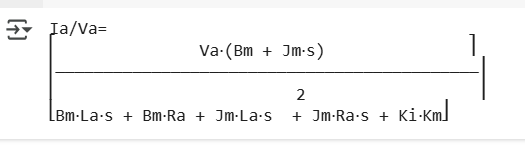

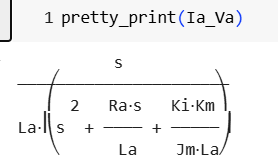

Sabiendo de https://colab.research.google.com/drive/1w2ue65U_jFG9fqHxgaLqPZ5NtRa6i33J?authuser=1#scrollTo=-nNJzDAK9nKS que


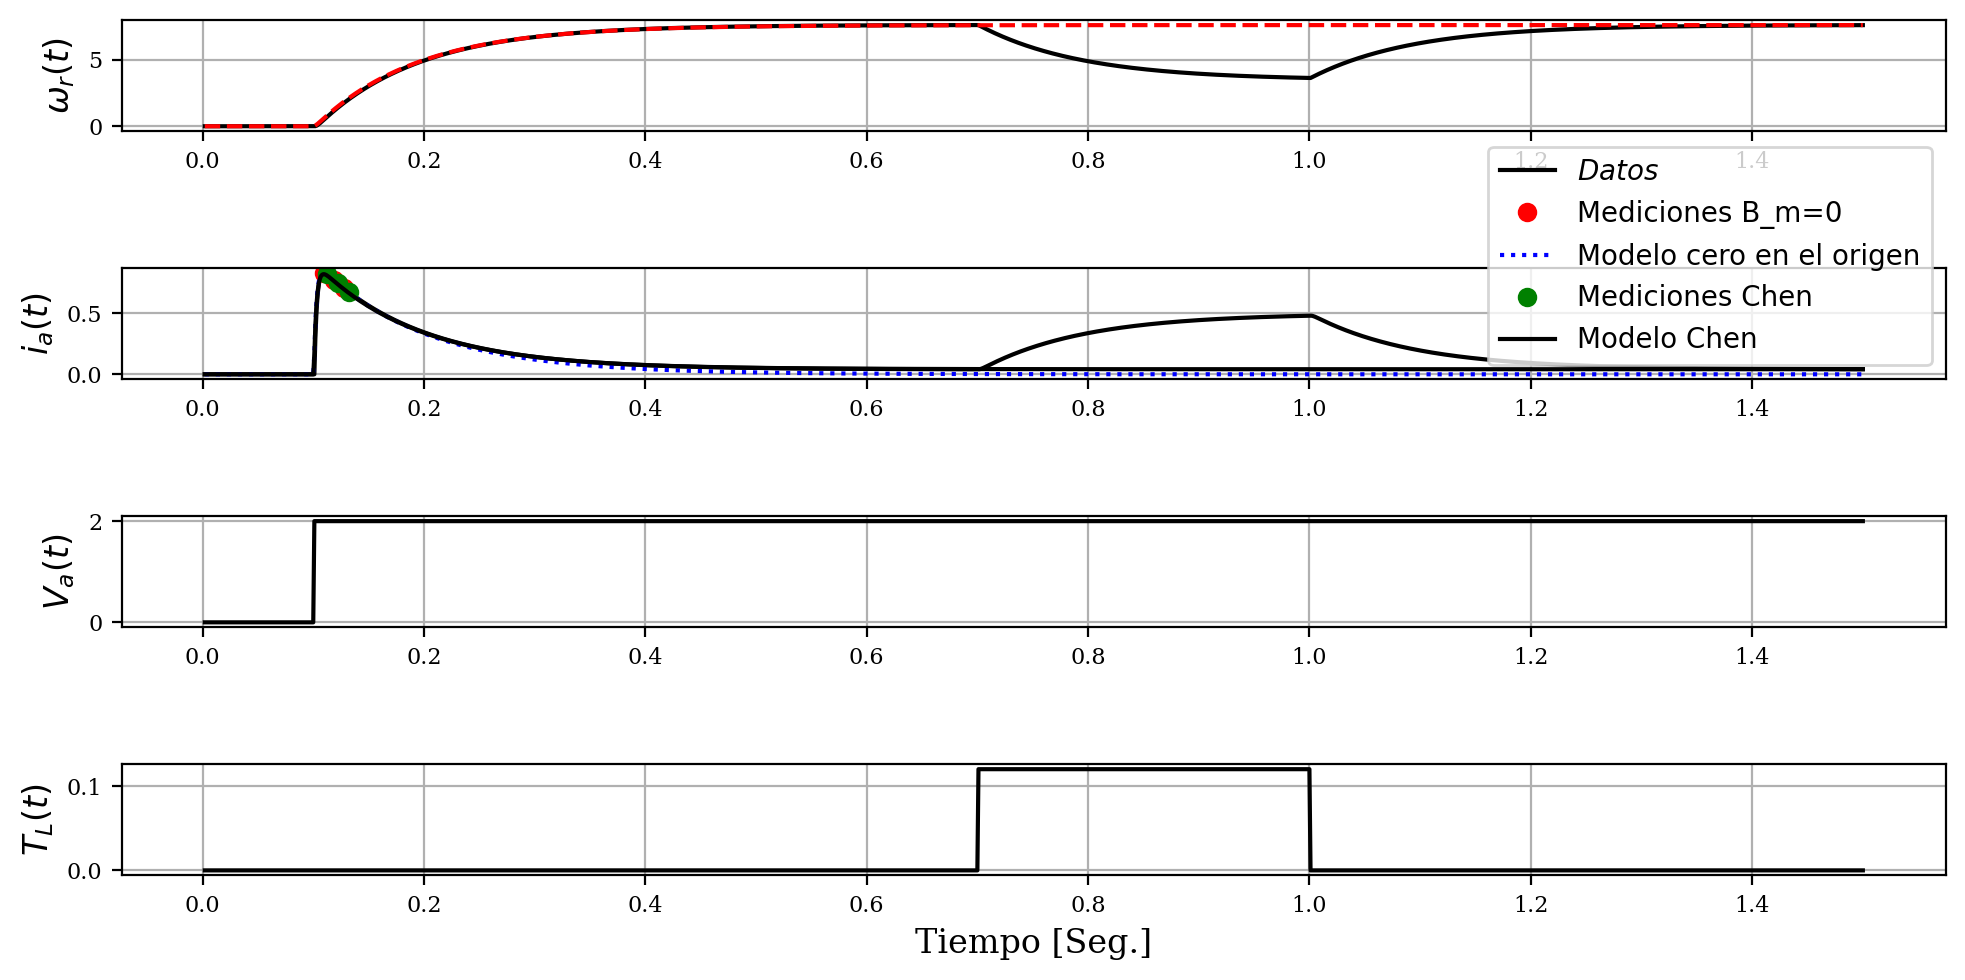

In [61]:
with plt.style.context('ieee'): #
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig10, ax13 = plt.subplots(4,1,figsize=(10,5), dpi= 200)
ax13[0].plot(df_Motor['t'],df_Motor['wr'])
ax13[0].plot(t_idw,y_idw)
ax13[1].legend([r'$Datos$' , r'Modelo Chen' ] )
ax13[0].set_ylabel(r'$\omega_r{(t)}$',rotation=90, fontsize=12)
ax13[0].grid( True )
ax13[1].plot(df_Motor['t'],df_Motor['i_t'])
ax13[1].plot([t1i,t2i,t3i],[uMAX*y1i,uMAX*y2i,uMAX*y3i],'o')
ax13[1].plot(t_1,y_1)
ax13[1].plot([t_t1, t_2t1, t_3t1], [y_t1,y_2t1,y_3t1],'o')
ax13[1].plot(t_id,y_id)
ax13[1].legend([r'$Datos$' , r'Mediciones B_m=0', r'Modelo cero en el origen',r'Mediciones Chen',r'Modelo Chen'] )
ax13[1].set_ylabel(r'$i_a{(t)}$',rotation=90, fontsize=12)
ax13[1].grid( True )
ax13[2].plot(df_Motor['t'],df_Motor['Vin'])
ax13[2].set_ylabel(r'$V_a{(t)}$',rotation=90, fontsize=12)
ax13[2].grid( True )
ax13[3].plot(df_Motor['t'],df_Motor['TL'])
ax13[3].set_ylabel(r'$T_L{(t)}$',rotation=90, fontsize=12)
ax13[3].grid( True )
ax13[3].set_xlabel(r'Tiempo [Seg.]',rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [90]:
# (Ra, La, Ki, Jm, Km))=
#  [((-T1*T2*T3 + T1 + T2)/K2_C, T1*T2/K2_C, K2_C*Ki*T3/K1_C, Ki, K2_C*Ki/K1_C, (T1*T3 - 1)*(T2*T3 - 1)/K1_C)]

# (-T1*T2*T3 + T1 + T2)/K2_C
(-T1*T2 + T3*(T1 + T2))/(K2_C*T3**2)


np.float64(2.27812289536069)

In [89]:
# sys_Gw_ang=K1_C*tf([T3_angw, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
# sys_G_ang=K2_C*tf([T3_ang, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
T3=T3_ang
T1=T1_angw;
T2=T2_angw #Salen de la funcion de la corriente respecto de Va
Ra_max=np.array(df['Vin']).max()/np.array(df['i_t']).max()
# # La=T1*T2/K2_C
# La=Ra*T1*T2/(T1 + T2)
# Ki=K1_C*Ra/K2_C
# Jm=(T1 + T2)/K2_C
# Km= 1/K1_C
# (Ra, La, Ki, Jm, Km))
# [(Ra, Ra*T1*T2/(T1 + T2), K1_C*Ra/K2_C, (T1 + T2)/K2_C, 1/K1_C)]
# ( Ra,La, Ki, Jm,Bm, Km))= [((-T1*T2 + T3*(T1 + T2))/(K2_C*T3**2), T1*T2/(K2_C*T3), Bm*K1_C/K2_C, Bm*T3, Bm, (T1*T2 + T3**2 - T3*(T1 + T2))/(K1_C*T3**2))]
Ra_max

np.float64(2.4135634665498813)

In [91]:
Ra=(-T1*T2 + T3*(T1 + T2))/(K2_C*T3**2)
Ra

np.float64(2.27812289536069)

In [92]:
La=T1*T2/(K2_C*T3)
La

np.float64(0.005187184919244552)

In [93]:
Ra=(-T1*T2 + T1*T3 + T2*T3)/(K2_C*T3**2)
Ra

np.float64(2.27812289536069)

In [94]:
Km=(T1*T2 + T3**2 - T3*(T1 + T2))/(K1_C*T3**2)
Km

np.float64(0.2499435593696499)

$Ki=\frac{K_1C}{K_{TL}}Ra$

In [96]:
K_TL=sys_T.num[0][0][1]

In [97]:
Ki=K1_C*Ra/K_TL
Ki

np.float64(0.26187117758701967)

In [98]:
Jm= K2_C*Ki*T3/K1_C
Jm

np.float64(0.0028487879744114276)

In [99]:
 Bm=K2_C*Ki/K1_C
 Bm

np.float64(0.0014279727330389093)

# Se obtienen los parámetros siguientes

In [100]:
K_TL=sys_T.num[0][0][1] #De la funcion de transferencia del torque sólo se emplea la ganancia
Ra=(-T1*T2 + T1*T3 + T2*T3)/(K2_C*T3**2)
La=T1*T2/(K2_C*T3)
Km=(T1*T2 + T3**2 - T3*(T1 + T2))/(K1_C*T3**2)
Ki=K1_C*Ra/K_TL
Jm= K2_C*Ki*T3/K1_C
Bm=K2_C*Ki/K1_C
print('Se obtienen los parámetros completos como \n','\nRa=',Ra,'\nLaa=',La, '\nKi=', Ki,'\nJm=',Jm,'\nBm=',Bm, '\nKb=', Km)
# Ra=2.27;Laa=0.0047;Ki=0.25;Kb=0.25;Bm=0.00131;Jm=0.00233; #%Motor real

Se obtienen los parámetros completos como 
 
Ra= 2.27812289536069 
Laa= 0.005187184919244552 
Ki= 0.26187117758701967 
Jm= 0.0028487879744114276 
Bm= 0.0014279727330389093 
Kb= 0.2499435593696499


In [ ]:
## Rutina Euler implementada en VE
# tout, y_D = sim_modelo(sys, ue, t) #éste debe ser Runge Kutta 4to orden, caso contrario el desempeño del LMS es  muy pobre
def sim_modelo(sys, ue, te):
    """
    Esta función hace evolucionar al modelo sys usando Euler con el vector ue de muestras equidistantes.
    """
    u = ue
    zi = np.zeros(len(te))
    etapa=te[20]-te[19]
    h=etapa/50. #Paso de integración
    veces=int(etapa/h)
    ord=len(sys.den[0][0])
    Mat_C = np.zeros([ord-1])
    ord_n=len(sys.num[0][0]) # Mat_C[]=sis_wr_va.num[0][0]
    # Normalizar el a0=1
    a0=sys.den[0][0][0]
    for nn in range(ord_n):
        # Mat_C[ord-2-nn]=sys.num[0][0][nn]/a0
        Mat_C[nn]=sys.num[0][0][ord_n-1-nn]/a0
    # Mat_C
    # Mat_C = np.array([[sys.num[1], sys.num[0]]])
    A = np.array([[0, 1], [-sys.den[0][0][2]/a0, -sys.den[0][0][1]/a0]])
    B = np.array([0, 1])
    x = np.array([0,0])
    print(A,B,Mat_C)
    for jj in range(1,len(te)):
        zi[jj]=Mat_C.T@x
        for ii in range(veces):
            xp=A@x+B*u[jj]
            x=x+xp*h
    return te, zi

In [101]:
# t_, y_sal
def modmotor(t_etapa, xant, accion):
    """
    Simula el modelo de un motor eléctrico para identificación.
    Parámetros:
    - t_etapa: duración de la etapa de simulación (segundos)
    - xant: estado anterior [ia, wr, tita_r]
    - accion: entrada [Va, TL]
    Retorna:
    - X: nuevo estado [ia, wr, tita_r]
    """
# Constantes Iniciales
#     Ra=2.27;Laa=0.0047;Ki=0.25;Kb=0.25;Bm=0.00131;Jm=0.00233; #%Motor inicial
# # Constantes Identificadas (son para calcular el controlador, Observador y PID)
    Ra= 2.27812289536069
    Laa= 0.005187184919244552
    Ki= 0.26187117758701967
    Jm= 0.0028487879744114276
    Bm= 0.0014279727330389093
    Kb= 0.2499435593696499
    h = 0.0004247701268049  # Paso de integración
    # Variables de estado
    ia, wr, titar = xant
    Va, TL = accion
    # Número de pasos de integración
    pasos = int(t_etapa / h)
    for _ in range(pasos):
        ia_p = -(Ra / Laa) * ia - (Kb / Laa) * wr + (1 / Laa) * Va
        wr_p = (Ki / Jm) * ia - (Bm / Jm) * wr - (1 / Jm) * TL
        ia += ia_p * h
        wr += wr_p * h
        titar += wr * h
    return np.array([ia, wr, titar])
At=df_Motor['t'][10]-df_Motor['t'][9]
X  = np.array([0.0, 0.0, 0.0])  # ia, wr, tita_r
wr_id=np.zeros(len(df_Motor['t']))
ia_id=np.zeros(len(df_Motor['t']))
for ii in range(len(df_Motor['t'])):
    wr_id[ii]=X[1]
    ia_id[ii]=X[0]
    X = modmotor(At, X , [df_Motor['Vin'][ii], df_Motor['TL'][ii]]  )
# print('Se obtienen los parámetros completos como \n','\nRa=',Ra,'\nLa=',La, '\nKi=', Ki,'\nJm=',Jm,'\nBm=',Bm, '\nKm=', Km)
ewr=df_Motor['wr']-wr_id
eia=df_Motor['i_t']-ia_id
mse_ewr=np.mean((ewr) ** 2)
mse_eia=np.mean((eia) ** 2)# mse = np.mean((y_true - y_pred) ** 2)
print('Se obtienen los mse ESCALON \n','\nmse_ewr=',mse_ewr,'\nmse_eia=',mse_eia) # print("Error Cuadrático Medio (MSE):", mse)

Se obtienen los mse ESCALON 
 
mse_ewr= 0.0470218877999149 
mse_eia= 0.0005853259546370607


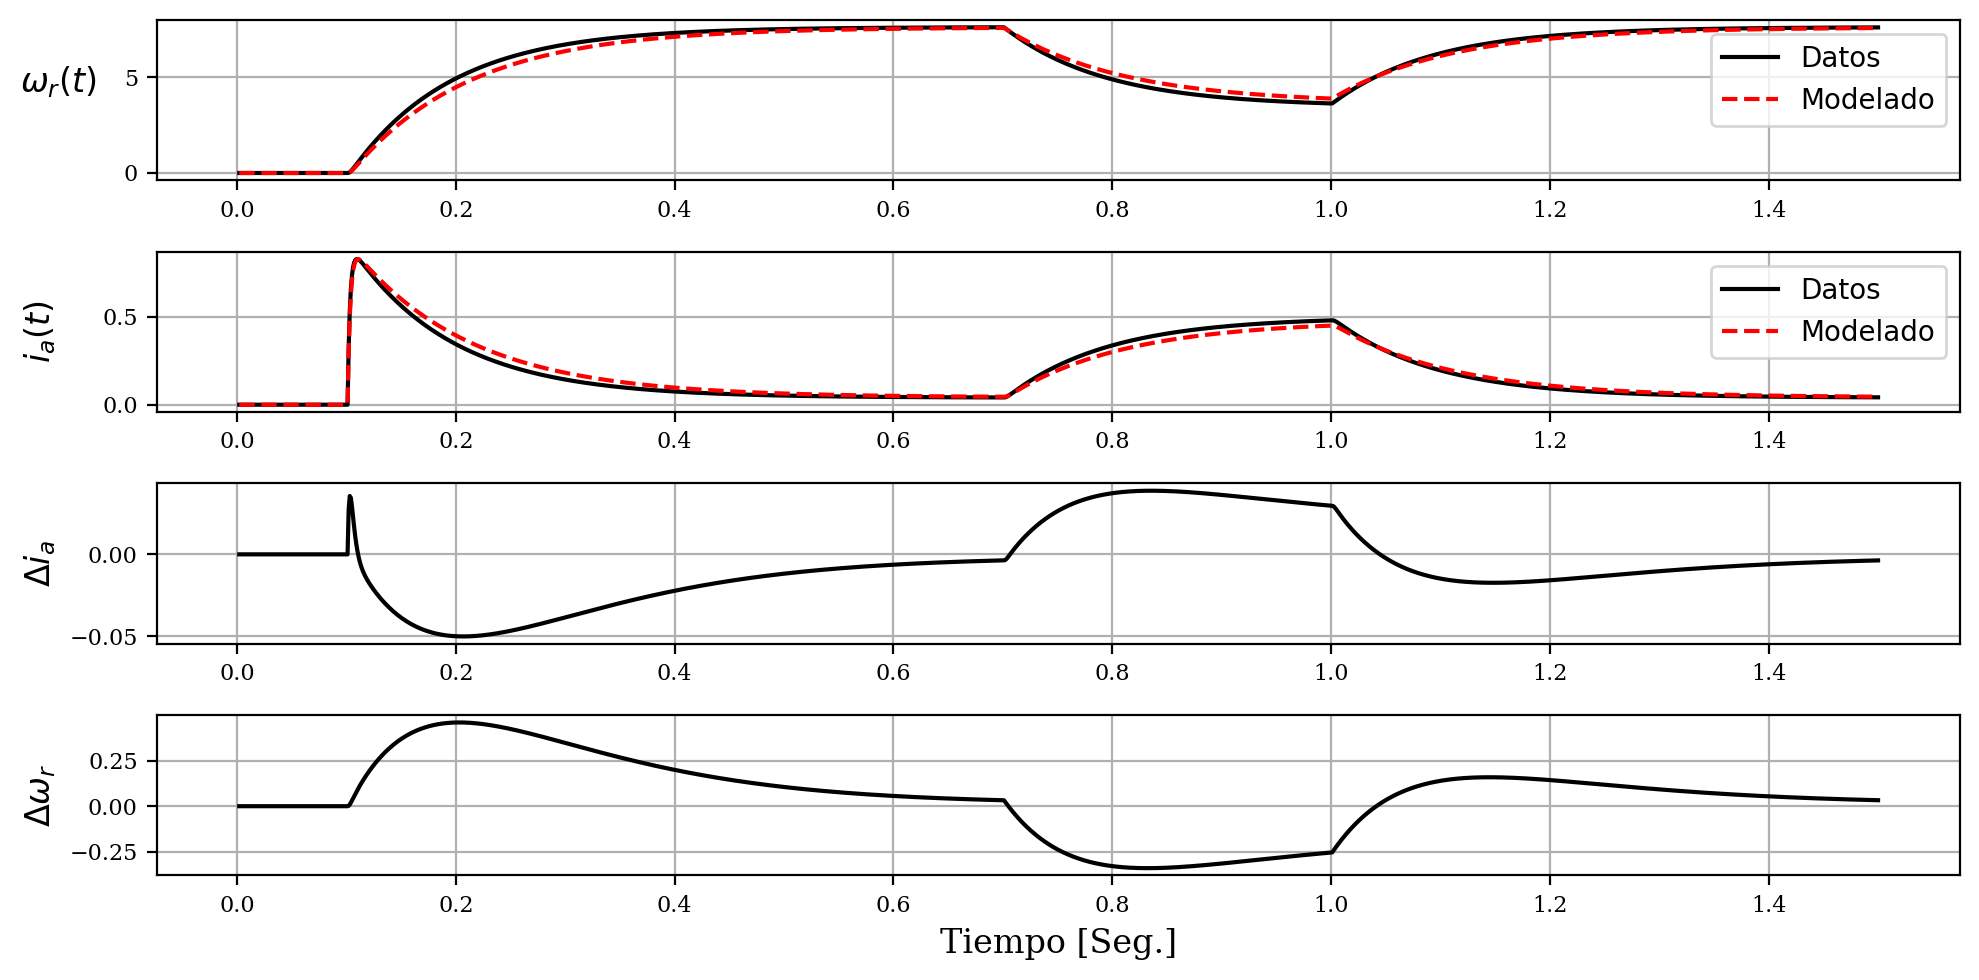

In [52]:
fs=12
with plt.style.context('ieee'): #
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig10, ax13 = plt.subplots(4,1,figsize=(10,5), dpi= 200)
ax13[0].plot(df_Motor['t'],df_Motor['wr'], label='Datos')
ax13[0].plot(df_Motor['t'],wr_id, label='Modelado')
# ax = fig.add_axes([0, 0, 1, 1])
# ax.set_yticks([0.5], labels=["very long label"])
ax13[0].legend()
ax13[0].set_ylabel(r'$\omega_r{(t)}$',rotation=0, fontsize=fs, )
ax13[0].grid( True )
ax13[1].plot(df_Motor['t'],df_Motor['i_t'], label='Datos')
ax13[1].plot(df_Motor['t'],ia_id, label='Modelado')
ax13[1].legend()
ax13[1].set_ylabel(r'$i_a{(t)}$',rotation=90, fontsize=fs)
ax13[1].grid( True )
ax13[2].plot(df_Motor['t'],df_Motor['i_t']-ia_id)
ax13[2].set_ylabel(r'$\Delta i_a $',rotation=90, fontsize=fs)
ax13[2].grid( True )
ax13[3].plot(df_Motor['t'],df_Motor['wr']-wr_id)
ax13[3].set_ylabel(r'$\Delta \omega_r$',rotation=90, fontsize=fs)
ax13[3].grid( True )
ax13[3].set_xlabel(r'Tiempo [Seg.]',rotation=0, fontsize=fs)
fig10.align_ylabels()
plt.tight_layout()
plt.show()

# Empleando el algoritmo LMS

$$Ft=\frac{b_1s+b_2}{a_0s^2+a_1s+a_2}$$
$$Ftnorm=K\frac{T_3s+1}{(T_1s+1)(T_2s+1)}$$
$$Ftnorm=K\frac{T_3s+1}{(T_1s+1)(T_2s+1)}$$
$$K=\frac{T_1T_2b_2}{a_0}$$
$$T_1=\frac{1}{\sigma_1}, T_2=\frac{1}{\sigma_2}$$

Respecto del Torque, desde Matlab, se obtiene
$$\frac{\omega_r}{T_L} =\frac{-3.84e-05 s^2 - 0.09413 s - 34.67}{0.0002106 s^2 + 0.09472 s + 1}$$

In [22]:
T2_LMS=1/10.8164
T1_LMS=1/438.945
T3_LMS=0.09413 / 34.67
K_TL_LMS=T1_LMS*T2_LMS*34.67/(0.0002106)
# sys_G_ang_LMS=K2_C*tf([T3_ang, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
sys_GwTL_ang_LMS=K_TL_LMS*tf([T3_LMS, 1],np.convolve([T1_LMS, 1],[T2_LMS, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
sys_GwTL_ang_LMS

TransferFunction(
array([ 0.09414057, 34.67389494]),
array([2.10623659e-04, 9.47303920e-02, 1.00000000e+00]),
outputs=1, inputs=1)

Desde Matlab, se obtiene
$$\frac{\omega_r}{V_a} =\frac{-4.228e-07 s^2 + 0.001064 s + 3.818}{0.0002106 s^2 + 0.09473 s + 1}$$

In [102]:
T2_LMS=1/10.8164
T1_LMS=1/438.9937
T3_LMS=0.001064/3.818
K1_C_LMS=T1_LMS*T2_LMS*3.818/(0.0002106)
# sys_G_ang_LMS=K2_C*tf([T3_ang, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
sys_Gw_ang_LMS=K1_C_LMS*tf([T3_LMS, 1],np.convolve([T1_LMS, 1],[T2_LMS, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
sys_Gw_ang_LMS

TransferFunction(
array([1.06400148e-03, 3.81800533e+00]),
array([2.10600294e-04, 9.47301392e-02, 1.00000000e+00]),
outputs=1, inputs=1)

In [103]:
sys_Gw_ang

TransferFunction(
array([3.14187251e-03, 3.81146846e+00]),
array([2.15078247e-04, 9.45664966e-02, 1.00000000e+00]),
outputs=1, inputs=1)

Desde Matlab, se obtiene
$$\frac{i_a}{V_a} =\frac{2.094e-05 s^2 + 0.04188 s + 0.02001}{0.0002106 s^2 + 0.09473 s + 1}$$


In [104]:
T2_LMS=1/10.8164
T1_LMS=1/438.9937
T3_LMS=0.04188 / 0.02001
K2_C_LMS=T1_LMS*T2_LMS*0.02001/(0.0002106)
# sys_G_ang_LMS=K2_C*tf([T3_ang, 1],np.convolve([T1_angw, 1],[T2_angw, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
sys_Gi_ang_LMS=K2_C_LMS*tf([T3_LMS, 1],np.convolve([T1_LMS, 1],[T2_LMS, 1])) # sys_G_ang=tf(K*[T3_ang 1],conv([T1_ang 1],[T2_ang 1]))
print(sys_Gi_ang_LMS)

<TransferFunction>: sys[78]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       0.04188 s + 0.02001
  -----------------------------
  0.0002106 s^2 + 0.09473 s + 1


In [105]:
sys_G_ang

TransferFunction(
array([0.04146339, 0.02078378]),
array([2.15078247e-04, 9.45664966e-02, 1.00000000e+00]),
outputs=1, inputs=1)

In [106]:
Ra_LMS=(-T1_LMS*T2_LMS + T1_LMS*T3_LMS + T2_LMS*T3_LMS)/(K2_C_LMS*T3_LMS**2)
La_LMS=T1_LMS*T2_LMS/(K2_C_LMS*T3_LMS)
Km_LMS=(T1_LMS - T3_LMS)*(T2_LMS - T3_LMS)/(K1_C_LMS*T3_LMS**2)
Ki_LMS=K1_C_LMS*Ra_LMS/K_TL_LMS
Jm_LMS= K2_C_LMS*Ki_LMS*T3_LMS/K1_C_LMS
Bm_LMS= K2_C_LMS*Ki_LMS/K1_C_LMS
print('Se obtienen los parámetros completos como empleando LMS \n','\nRa=',Ra_LMS,'\nLaa=',La_LMS, '\nKi=', Ki_LMS,'\nJm=',Jm_LMS,'\nBm=',Bm_LMS, '\nKb=', Km_LMS)

Se obtienen los parámetros completos como empleando LMS 
 
Ra= 2.2595363827021124 
Laa= 0.0050286532951289405 
Ki= 0.24880164056272228 
Jm= 0.002729128524559143 
Bm= 0.0013039604053588457 
Kb= 0.25007472020925575


In [ ]:
Ra= 2.2595363827021124
La= 0.0050286532951289405
Ki= 0.24880164056272228
Jm= 0.002729128524559143
Bm= 0.0013039604053588457
Km= 0.25007472020925575

In [107]:
# t_, y_sal
def modmotor(t_etapa, xant, accion):
    """
    Simula el modelo de un motor eléctrico para identificación.
    Parámetros:
    - t_etapa: duración de la etapa de simulación (segundos)
    - xant: estado anterior [ia, wr, tita_r]
    - accion: entrada [Va, TL]
    Retorna:
    - X: nuevo estado [ia, wr, tita_r]
    """
# Constantes Iniciales
    # Ra=2.27;Laa=0.0047;Ki=0.25;Kb=0.25;Bm=0.00131;Jm=0.00233; #%Motor real
# Constantes Identificadas (son para calcular el controlador, Observador y PID)
    Ra= 2.2595363827021124
    Laa= 0.0050286532951289405
    Ki= 0.24880164056272228
    Jm= 0.002729128524559143
    Bm= 0.0013039604053588457
    Kb= 0.25007472020925575
    h = 0.0004247701268049  # Paso de integración
    # Laa=500e-6; Jm=2.5e-9; Ra=20; Bm=0;Ki=10e-3; Kb=60.53e-3; #%TP 2025
    # Variables de estado
    ia, wr, titar = xant
    Va, TL = accion
    # Número de pasos de integración
    pasos = int(t_etapa / h)
    for _ in range(pasos):
        ia_p = -(Ra / Laa) * ia - (Kb / Laa) * wr + (1 / Laa) * Va
        wr_p = (Ki / Jm) * ia - (Bm / Jm) * wr - (1 / Jm) * TL
        ia += ia_p * h
        wr += wr_p * h
        titar += wr * h
    return np.array([ia, wr, titar])
At=df_Motor['t'][10]-df_Motor['t'][9]
X  = np.array([0.0, 0.0, 0.0])  # ia, wr, tita_r
wr_id_LMS=np.zeros(len(df_Motor['t']))
ia_id_LMS=np.zeros(len(df_Motor['t']))
for ii in range(len(df_Motor['t'])):
    wr_id_LMS[ii]=X[1]
    ia_id_LMS[ii]=X[0]
    X = modmotor(At, X , [df_Motor['Vin'][ii], df_Motor['TL'][ii]]  )
# print('Se obtienen los parámetros completos como \n','\nRa=',Ra,'\nLa=',La, '\nKi=', Ki,'\nJm=',Jm,'\nBm=',Bm, '\nKm=', Km)
ewr_LMS=df_Motor['wr']-wr_id_LMS
eia_LMS=df_Motor['i_t']-ia_id_LMS
mse_ewr_LMS=np.mean((ewr_LMS) ** 2)
mse_eia_LMS=np.mean((eia_LMS) ** 2)# mse = np.mean((y_true - y_pred) ** 2)
print('Se obtienen los mse LMS  \n','\nmse_ewr=',mse_ewr_LMS,'\nmse_eia=',mse_eia_LMS) # print("Error Cuadrático Medio (MSE):", mse)

Se obtienen los mse LMS  
 
mse_ewr= 0.03723746164561288 
mse_eia= 0.00047609404259623653


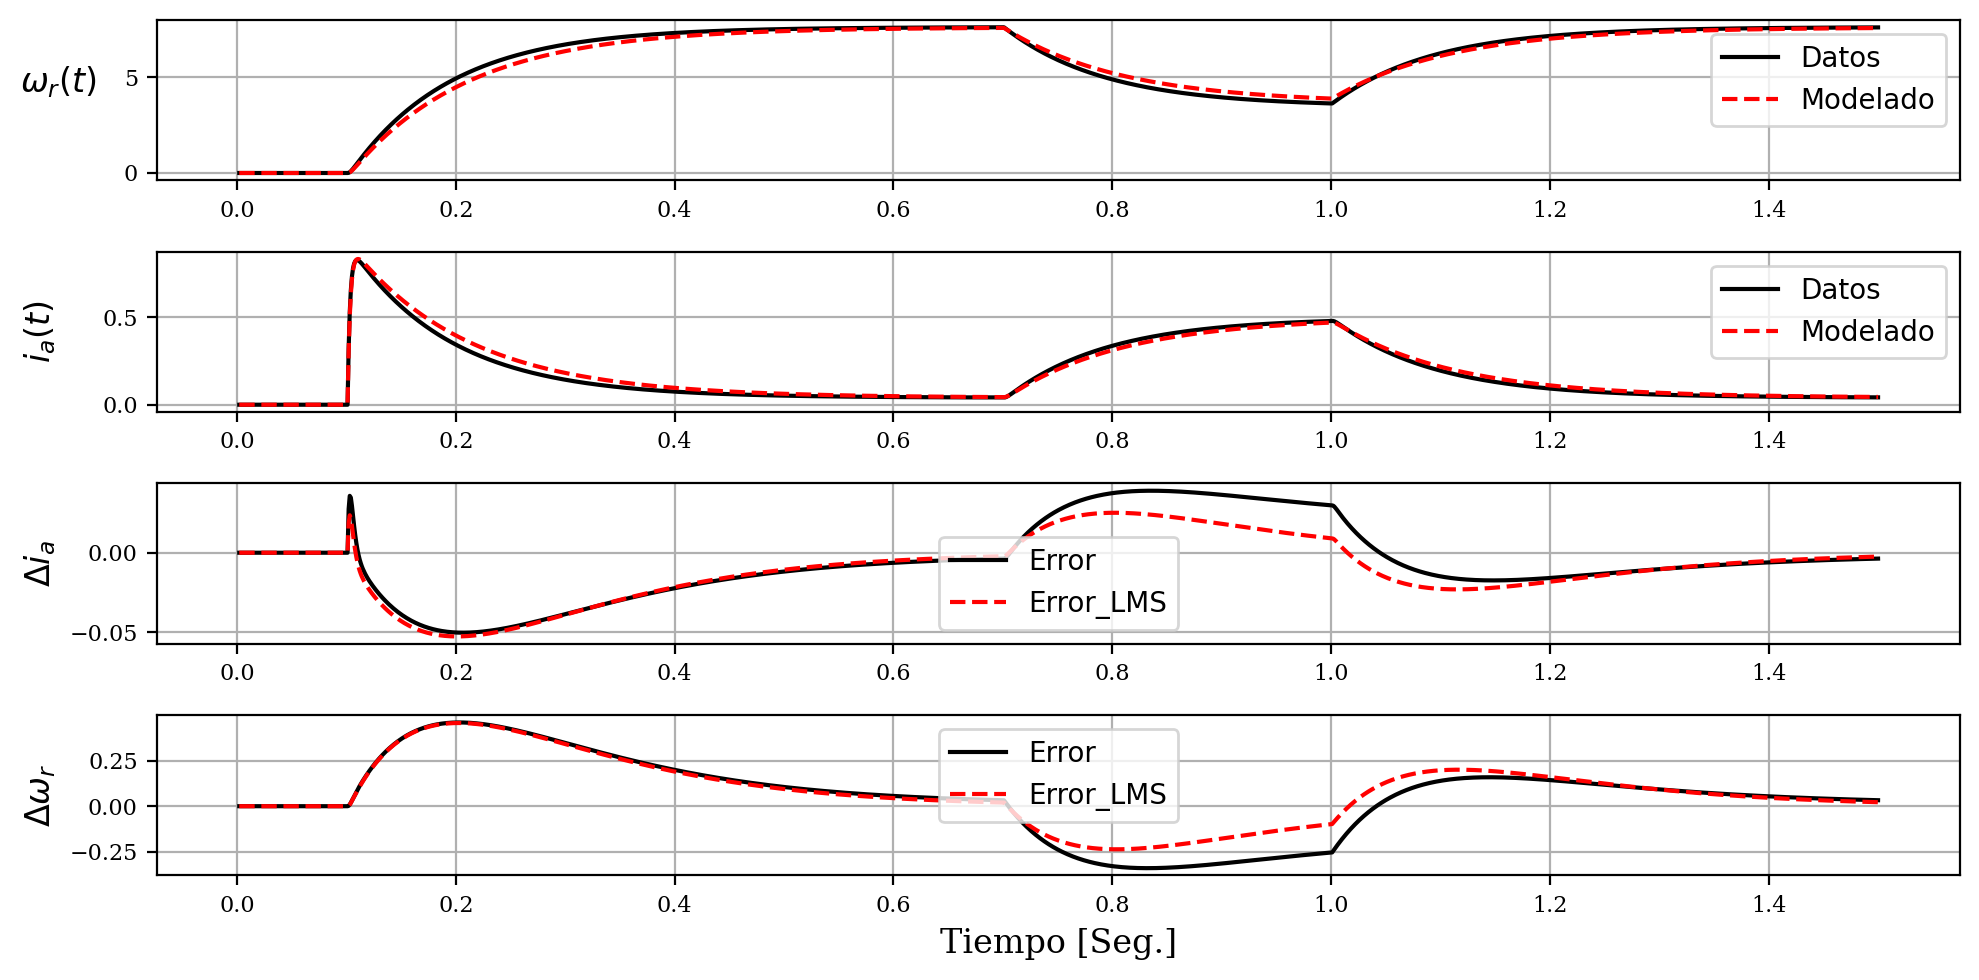

In [108]:
fs=12
with plt.style.context('ieee'): #
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig10, ax13 = plt.subplots(4,1,figsize=(10,5), dpi= 200)
ax13[0].plot(df_Motor['t'],df_Motor['wr'], label='Datos')
ax13[0].plot(df_Motor['t'],wr_id, label='Modelado')
# ax = fig.add_axes([0, 0, 1, 1])
# ax.set_yticks([0.5], labels=["very long label"])
ax13[0].legend()
ax13[0].set_ylabel(r'$\omega_r{(t)}$',rotation=0, fontsize=fs, )
ax13[0].grid( True )
ax13[1].plot(df_Motor['t'],df_Motor['i_t'], label='Datos')
ax13[1].plot(df_Motor['t'],ia_id_LMS, label='Modelado')
ax13[1].legend()
ax13[1].set_ylabel(r'$i_a{(t)}$',rotation=90, fontsize=fs)
ax13[1].grid( True )
ax13[2].plot(df_Motor['t'],df_Motor['i_t']-ia_id, label='Error')
ax13[2].plot(df_Motor['t'],df_Motor['i_t']-ia_id_LMS,label='Error_LMS')
ax13[2].legend()
ax13[2].set_ylabel(r'$\Delta i_a $',rotation=90, fontsize=fs)
ax13[2].grid( True )
ax13[3].plot(df_Motor['t'],df_Motor['wr']-wr_id, label='Error')
ax13[3].plot(df_Motor['t'],df_Motor['wr']-wr_id_LMS,label='Error_LMS')
ax13[3].legend()
ax13[3].set_ylabel(r'$\Delta \omega_r$',rotation=90, fontsize=fs)
ax13[3].grid( True )
ax13[3].set_xlabel(r'Tiempo [Seg.]',rotation=0, fontsize=fs)
fig10.align_ylabels()
plt.tight_layout()
plt.show()

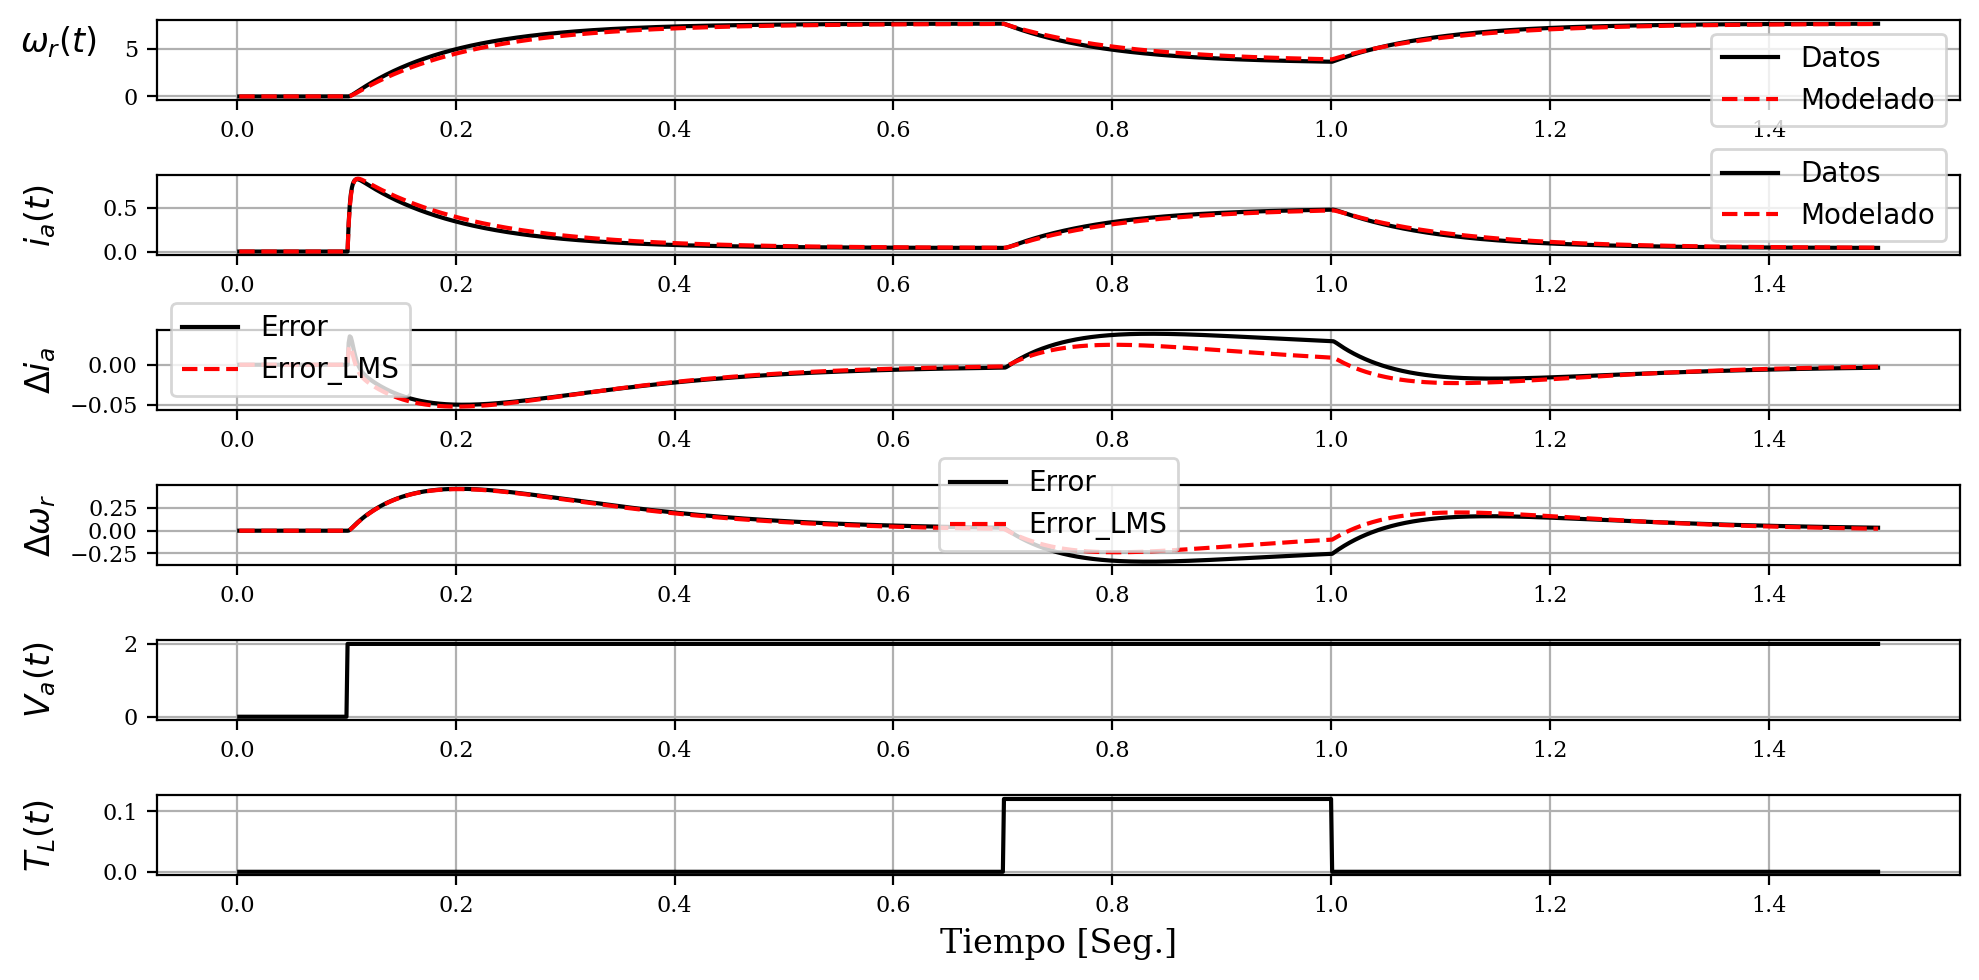

In [109]:
fs=12
with plt.style.context('ieee'): #
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig10, ax13 = plt.subplots(6,1,figsize=(10,5), dpi= 200)
ax13[0].plot(df_Motor['t'],df_Motor['wr'], label='Datos')
ax13[0].plot(df_Motor['t'],wr_id, label='Modelado')
# ax = fig.add_axes([0, 0, 1, 1])
# ax.set_yticks([0.5], labels=["very long label"])
ax13[0].legend()
ax13[0].set_ylabel(r'$\omega_r{(t)}$',rotation=0, fontsize=fs, )
ax13[0].grid( True )
ax13[1].plot(df_Motor['t'],df_Motor['i_t'], label='Datos')
ax13[1].plot(df_Motor['t'],ia_id_LMS, label='Modelado')
ax13[1].legend()
ax13[1].set_ylabel(r'$i_a{(t)}$',rotation=90, fontsize=fs)
ax13[1].grid( True )
ax13[2].plot(df_Motor['t'],df_Motor['i_t']-ia_id, label='Error')
ax13[2].plot(df_Motor['t'],df_Motor['i_t']-ia_id_LMS,label='Error_LMS')
ax13[2].legend()
ax13[2].set_ylabel(r'$\Delta i_a $',rotation=90, fontsize=fs)
ax13[2].grid( True )
ax13[3].plot(df_Motor['t'],df_Motor['wr']-wr_id, label='Error')
ax13[3].plot(df_Motor['t'],df_Motor['wr']-wr_id_LMS,label='Error_LMS')
ax13[3].legend()
ax13[3].set_ylabel(r'$\Delta \omega_r$',rotation=90, fontsize=fs)
ax13[3].grid( True )
ax13[4].plot(df_Motor['t'],df_Motor['Vin'])
ax13[4].set_ylabel(r'$V_a{(t)}$',rotation=90, fontsize=12)
ax13[4].grid( True )
ax13[5].plot(df_Motor['t'],df_Motor['TL'])
ax13[5].set_ylabel(r'$T_L{(t)}$',rotation=90, fontsize=12)
ax13[5].grid( True )

ax13[5].set_xlabel(r'Tiempo [Seg.]',rotation=0, fontsize=fs)
fig10.align_ylabels()
plt.tight_layout()
plt.show()
